In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import sys
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

In [2]:
data_path = '/Users/june/Documents/data/tabular_process_param'
file_name = 'secom.csv'

full_path = os.path.join(data_path, file_name)

with open(full_path, 'rb') as f:
    data = pd.read_csv(f)


In [3]:
data['Pass/Fail'] = data['Pass/Fail'].map({-1: 0, 1: 1})
data.head()


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,0
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0


In [4]:
defect_rate = data['Pass/Fail'].value_counts()[1] / (data['Pass/Fail'].value_counts()[1] + data['Pass/Fail'].value_counts()[0])

In [5]:
data.shape

(1567, 592)

In [6]:
data.head()


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,0
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,0
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,0
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,0


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

ImputingMethods = ['mean', 'median', 'most_frequent']
accuracy_scores = []
best_score = 0
best_fit = None

for method in ImputingMethods:
    # Train-Test Split FIRST!
    X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['Pass/Fail', 'Time'], axis=1), data['Pass/Fail'], test_size=0.2, random_state=42
)

    for method in ImputingMethods:
        imputer = SimpleImputer(strategy=method)
    
        # Fit on training data only
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)  # Transform test data without fitting again
    
        # Convert back to DataFrame
        X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
        X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

        # Train Model
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train_imputed, y_train)

        # Evaluate Model
        score = model.score(X_test_imputed, y_test)
        accuracy_scores.append(score)

        print(f'Imputing Method: {method}, Accuracy: {score:.9f}')

        # Track best model
        if score > best_score:
            best_score = score
      
            best_fit = model

# Now fill in the NaN values in the original dataset for the best method
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data.drop(['Pass/Fail', 'Time'], axis=1))
data_imputed = pd.DataFrame(data_imputed, columns=data.drop(['Pass/Fail', 'Time'], axis=1).columns)



Imputing Method: mean, Accuracy: 0.923566879
Imputing Method: median, Accuracy: 0.923566879
Imputing Method: most_frequent, Accuracy: 0.923566879
Imputing Method: mean, Accuracy: 0.923566879
Imputing Method: median, Accuracy: 0.923566879
Imputing Method: most_frequent, Accuracy: 0.923566879
Imputing Method: mean, Accuracy: 0.923566879
Imputing Method: median, Accuracy: 0.923566879
Imputing Method: most_frequent, Accuracy: 0.923566879


In [8]:
# EDA strategies
# 1. Find the 50 most crucial features to determine the pass/fail - Run ANOVA
# 2. Look at the distribution of the features
# 3. Look at correlation between features and target plus features and features
# 4. Look at the distribution of the target
# 5. dimensionality reduction and clustering

In [9]:
# 50 most crucial features
from sklearn.feature_selection import SelectKBest, f_classif

data_imputed['Pass/Fail'] = data['Pass/Fail']
selector = SelectKBest(f_classif, k=25)
selector.fit(data_imputed.drop('Pass/Fail', axis=1), data_imputed['Pass/Fail'])

selected_features = pd.DataFrame(data_imputed.drop('Pass/Fail', axis=1).columns[selector.get_support()])

/Users/june/miniconda3/envs/pytorch/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  5  13  42  49  52  69  97 141 149 178 179 186 189 190 191 192 193 194
 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256 257 258 259
 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326 327 328 329
 330 364 369 370 371 372 373 374 375 378 379 380 381 394 395 396 397 398
 399 400 401 402 403 404 414 422 449 450 451 458 461 462 463 464 465 466
 481 498 501 502 503 504 505 506 507 508 509 512 513 514 515 528 529 530
 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/june/miniconda3/envs/pytorch/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [10]:
# create dataframe with selected features and leave the selected columns only
data_selected = data_imputed[selected_features[0].values]
data_selected['Pass/Fail'] = data_imputed['Pass/Fail']

data_selected


/var/folders/xs/5688kgc54c12jm1b6pjmrldr0000gn/T/ipykernel_38093/867530849.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_selected['Pass/Fail'] = data_imputed['Pass/Fail']


,21,28,59,103,121,124,125,129,160,163,...,300,316,348,430,431,434,435,436,510,Pass/Fail
0,-5419.00,64.2333,-1.7264,-0.0042,15.880000,15.930000,0.865600,-0.047300,967.0,0.090,...,0.0462,6.2698,0.021500,18.7673,33.1562,10.0503,2.7073,3.1158,64.6707,0
1,-5441.50,68.4222,0.8073,-0.0045,15.880000,15.880000,0.870300,-0.094600,59.0,0.112,...,0.0591,5.6522,0.014200,10.4383,2.2655,8.6336,5.7093,1.6779,141.4365,0
2,-5447.75,67.1333,23.8245,-0.0026,15.900000,15.950000,0.879800,-0.189200,788.0,0.187,...,0.0326,5.7247,0.010500,10.3162,29.1663,14.2503,5.7650,0.8972,240.7767,1
3,-5468.25,62.9333,24.3791,-0.0059,15.550000,15.590000,1.366000,0.283800,355.0,0.068,...,0.0465,5.4440,0.040700,15.7089,13.4051,5.1760,5.3899,1.3671,113.5593,0
4,-5476.25,62.8333,-12.2945,-0.0045,15.750000,15.710000,0.946000,-0.567700,283.0,0.147,...,0.0476,4.8956,0.024600,12.7642,10.7390,11.4064,2.0088,1.5533,148.0663,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,-5418.75,71.1444,2.8182,-0.0094,15.690000,15.670000,1.541000,0.000000,334.0,0.123,...,0.1242,7.5769,0.024706,23.6217,12.8067,9.5963,8.1372,3.6727,53.1915,0
1563,-6408.75,72.8444,-3.3555,-0.0116,15.920000,15.870000,1.309000,-0.141900,94.0,0.055,...,0.1347,6.4134,0.024706,7.8642,4.1273,5.0598,2.3859,5.2024,29.4372,0
1564,-5153.25,71.2667,1.1664,-0.0142,15.796425,15.794705,1.184956,-0.554228,542.0,0.109,...,0.1258,6.9172,0.024706,22.8594,20.0222,8.4300,3.8076,3.7752,54.8330,0
1565,-5271.75,70.5111,4.4682,-0.0087,15.720000,15.720000,1.385000,-0.993400,252.0,0.098,...,0.1185,7.5822,0.024706,33.0061,9.4153,7.6117,9.7082,3.4127,78.4993,0


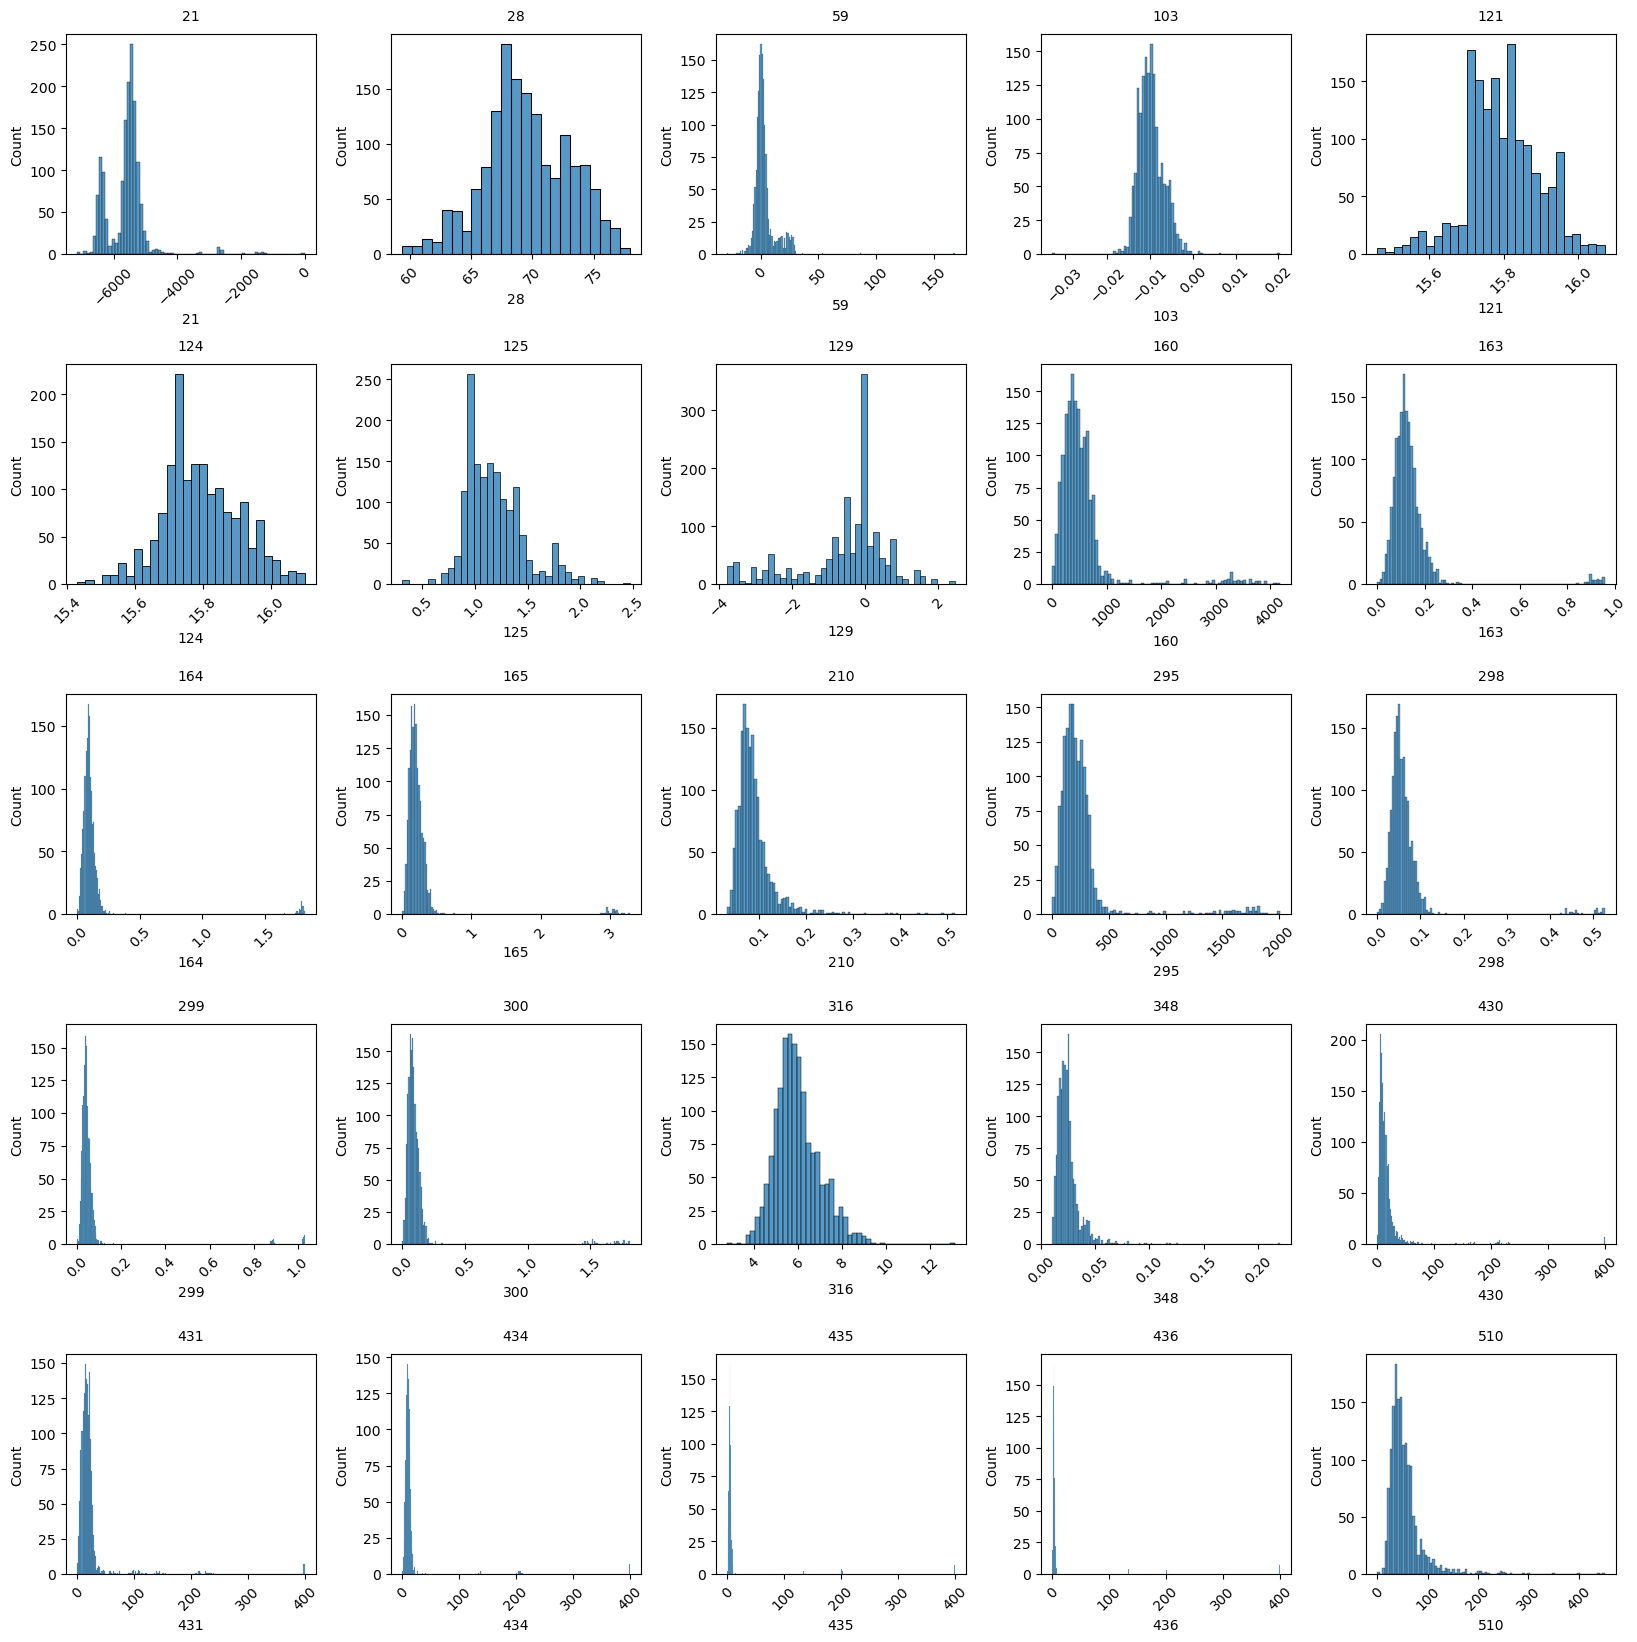

In [11]:
# subplot 10x5 of each column distribution as bar plots
fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for i, ax in enumerate(axes.flatten()):
    if i < data_selected.shape[1]:
        sns.histplot(data_selected.iloc[:, i], ax=ax)
        ax.set_title(data_selected.columns[i], fontsize=10, pad=10)  # Increase padding for spacing
        ax.tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability
    else:
        ax.set_visible(False)

plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Adjust spacing between plots
plt.show()


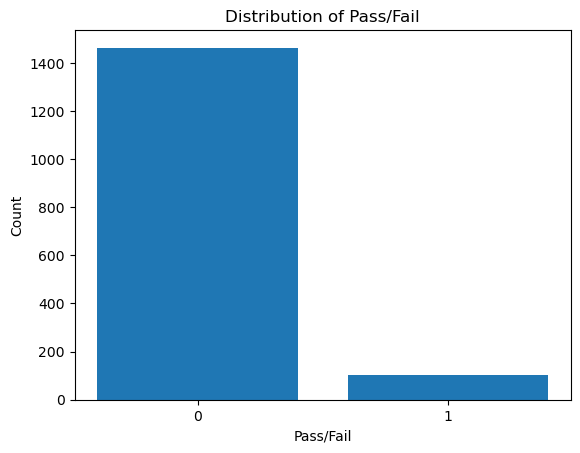

In [12]:
# Plotting the distribution of the target using bar plot
plt.bar(data_selected['Pass/Fail'].value_counts().index, data_selected['Pass/Fail'].value_counts().values)
plt.xticks([0, 1])
plt.xlabel('Pass/Fail')
plt.ylabel('Count')
plt.title('Distribution of Pass/Fail')
plt.show()


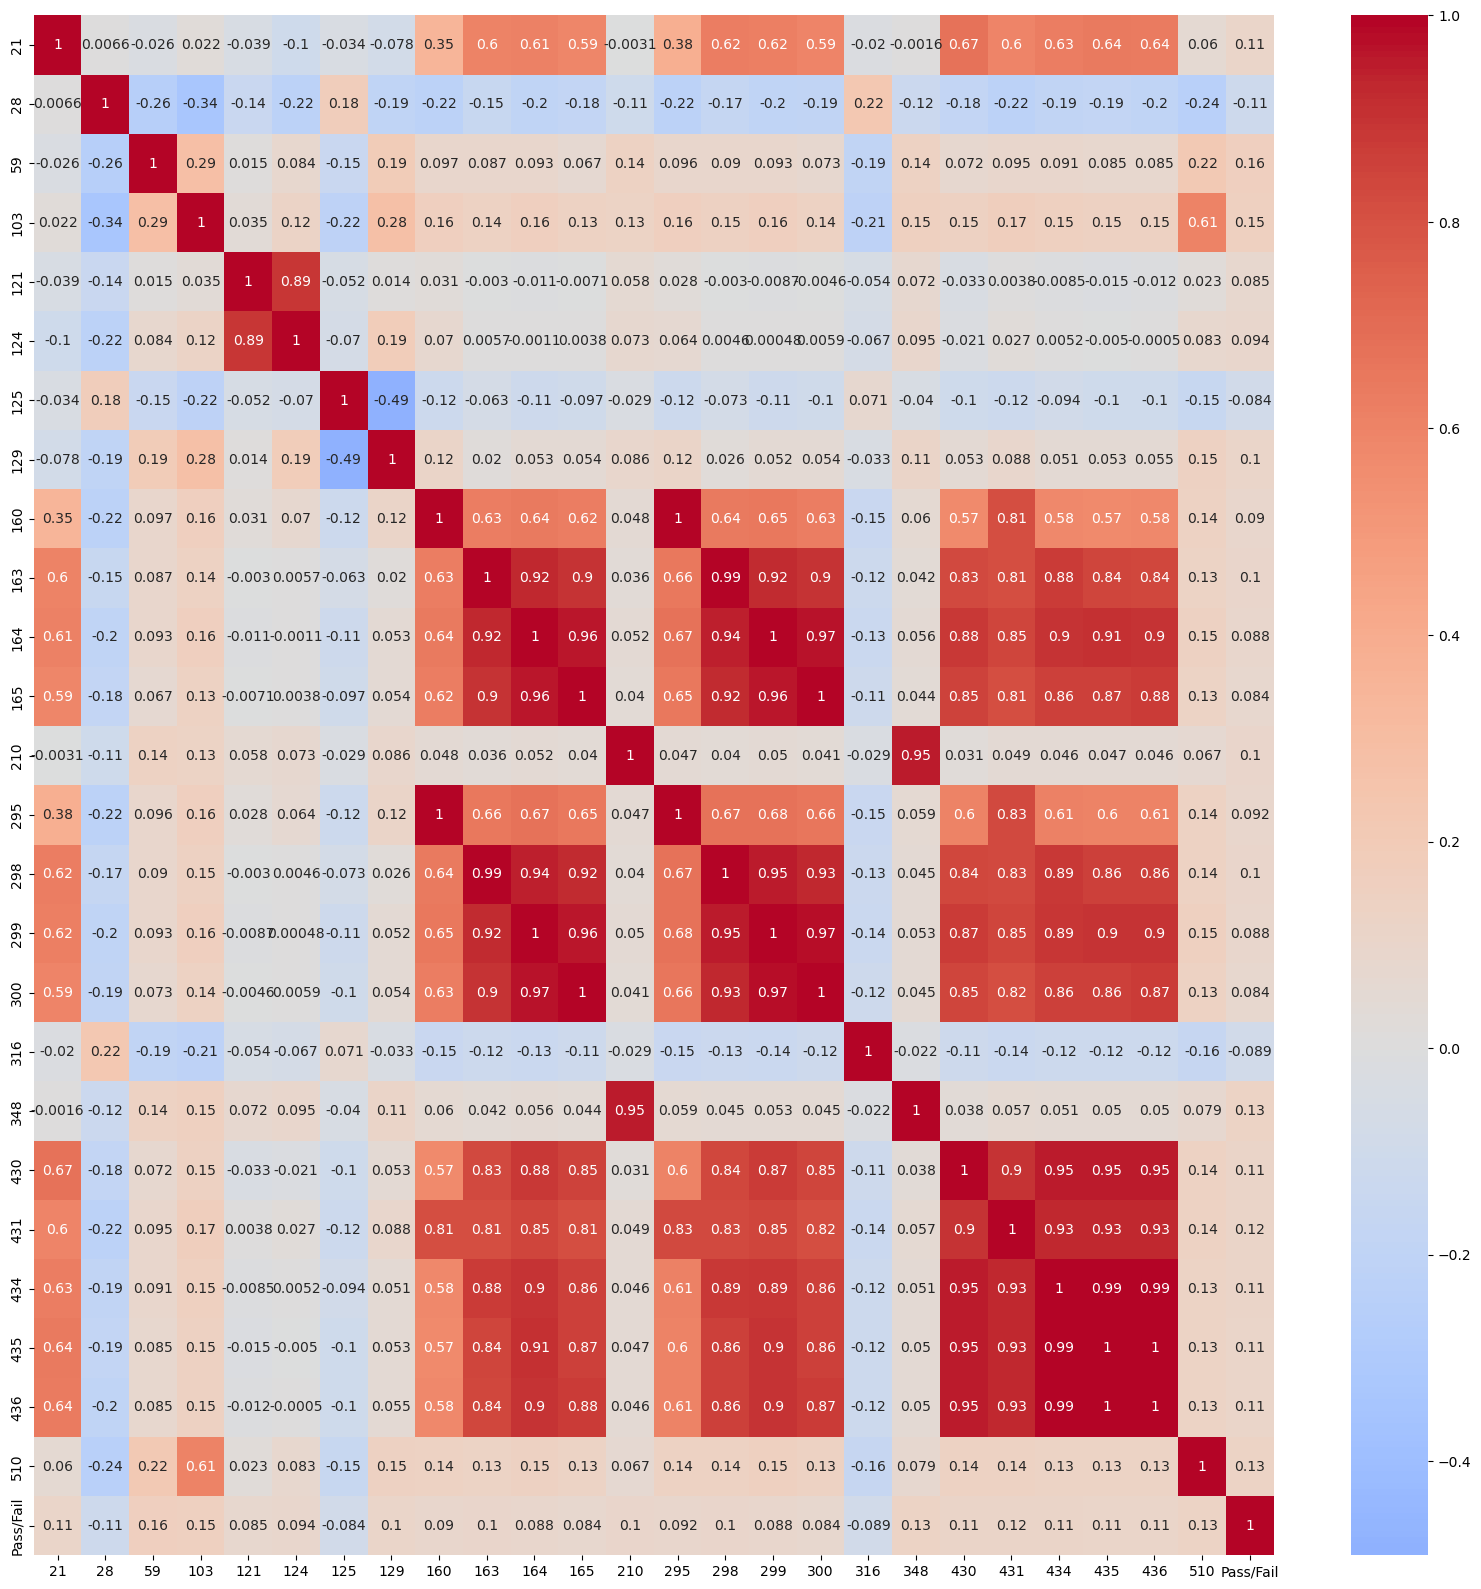

In [16]:
# View correlation between features and target plus features and features
plt.figure(figsize=(20, 20))
sns.heatmap(data_selected.corr(), annot=True, cmap='coolwarm', center=0)
plt.show()


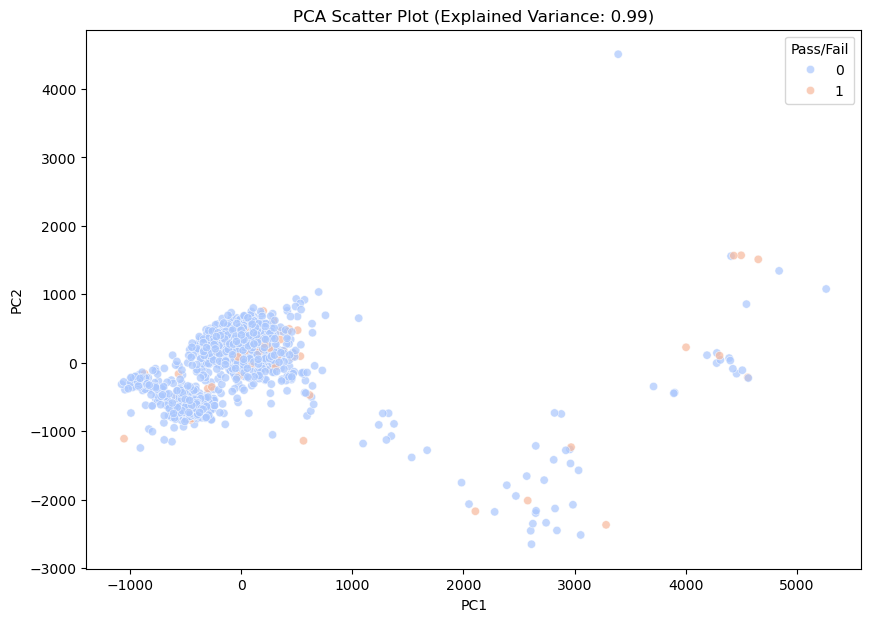

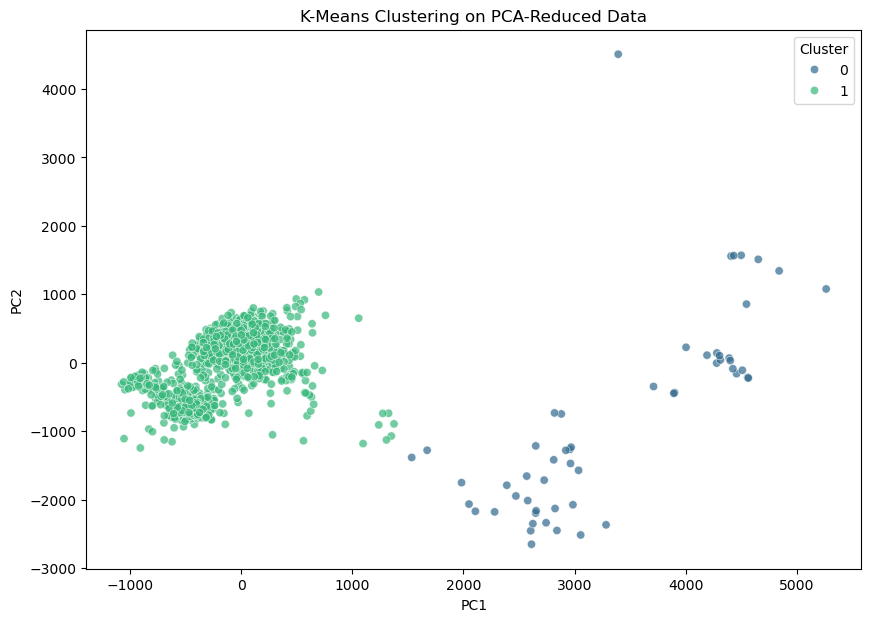

Silhouette Score (Clustering Quality): 0.8274


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1️⃣ Apply PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_selected.drop('Pass/Fail', axis=1))

# Convert to DataFrame
data_pca = pd.DataFrame(data_pca, columns=['PC1', 'PC2'])
data_pca['Pass/Fail'] = data_selected['Pass/Fail'].values  # Add labels back

# 2️⃣ PCA Scatter Plot (Color by Pass/Fail)
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=data_pca, hue=data_pca['Pass/Fail'], palette='coolwarm', alpha=0.7)
plt.title(f'PCA Scatter Plot (Explained Variance: {sum(pca.explained_variance_ratio_):.2f})')
plt.show()

# 3️⃣ K-Means Clustering on PCA-Transformed Data
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(data_pca[['PC1', 'PC2']])
data_pca['Cluster'] = clusters  # Assign clusters

# 4️⃣ Compare K-Means Clusters with Pass/Fail Labels
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=data_pca, hue=data_pca['Cluster'], palette='viridis', alpha=0.7)
plt.title('K-Means Clustering on PCA-Reduced Data')
plt.show()

# 5️⃣ Evaluate Clustering Quality
silhouette = silhouette_score(data_pca[['PC1', 'PC2']], clusters)
print(f'Silhouette Score (Clustering Quality): {silhouette:.4f}')
